## Step 0: Install Dependencies

In [ ]:
!pip install -q xgboost lightgbm catboost shap dice-ml deap openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.9/866.9 kB 47.2 MB/s eta 0:00:00


## Step 0b: Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Step 1: Data Loading

In [ ]:
from google.colab import files

# Uncomment to upload interactively in Colab:
uploaded = files.upload()

df = pd.read_excel("ENB2012_data.xlsx")
print("Shape:", df.shape)
df.head()

Saving ENB2012_data.xlsx to ENB2012_data.xlsx
Shape: (768, 10)


,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      768 non-null    float64
 1   X2      768 non-null    float64
 2   X3      768 non-null    float64
 3   X4      768 non-null    float64
 4   X5      768 non-null    float64
 5   X6      768 non-null    int64  
 6   X7      768 non-null    float64
 7   X8      768 non-null    int64  
 8   Y1      768 non-null    float64
 9   Y2      768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


## Step 2: Feature Selection

In [ ]:
X = df.iloc[:, 0:8]
Y = df.iloc[:, 8:10]

feature_names = X.columns.tolist()
target_names = Y.columns.tolist()

print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("Features:", feature_names)
print("Targets:", target_names)

X shape: (768, 8)
Y shape: (768, 2)
Features: ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8']
Targets: ['Y1', 'Y2']


## Step 3: Data Preprocessing

### 3a. Missing Value Check

In [ ]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)
print("\nTotal missing values:", missing.sum())

Missing values per column:
X1    0
X2    0
X3    0
X4    0
X5    0
X6    0
X7    0
X8    0
Y1    0
Y2    0
dtype: int64

Total missing values: 0


### 3b. Duplicate Check

In [ ]:
n_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {n_duplicates}")

if n_duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    X = df.iloc[:, 0:8]
    Y = df.iloc[:, 8:10]
    print(f"Duplicates removed. New shape: {df.shape}")
else:
    print("No duplicates found.")

Number of duplicate rows: 0
No duplicates found.


## Step 4: Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("y_train:", y_train.shape, " y_test:", y_test.shape)

X_train: (614, 8)  X_test: (154, 8)
y_train: (614, 2)  y_test: (154, 2)


## Step 5: Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=feature_names,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_names,
    index=X_test.index
)

X_train_scaled.head()

,X1,X2,X3,X4,X5,X6,X7,X8
60,0.553671,-0.696222,-0.007372,-0.679048,1.016421,-1.364411,-1.010300,-1.160598
618,-1.155118,1.250664,0.558439,0.957063,-0.983844,0.441081,1.227790,-0.515705
346,0.933402,-0.974349,-0.573184,-0.679048,1.016421,0.441081,0.108745,-0.515705
294,1.313133,-1.252476,-0.007372,-1.224418,1.016421,0.441081,0.108745,-1.160598
231,-0.965252,0.972537,-0.007372,0.957063,-0.983844,1.343827,-1.010300,0.774082


## Step 6: Exploratory Data Analysis

### 6a. Target Distribution

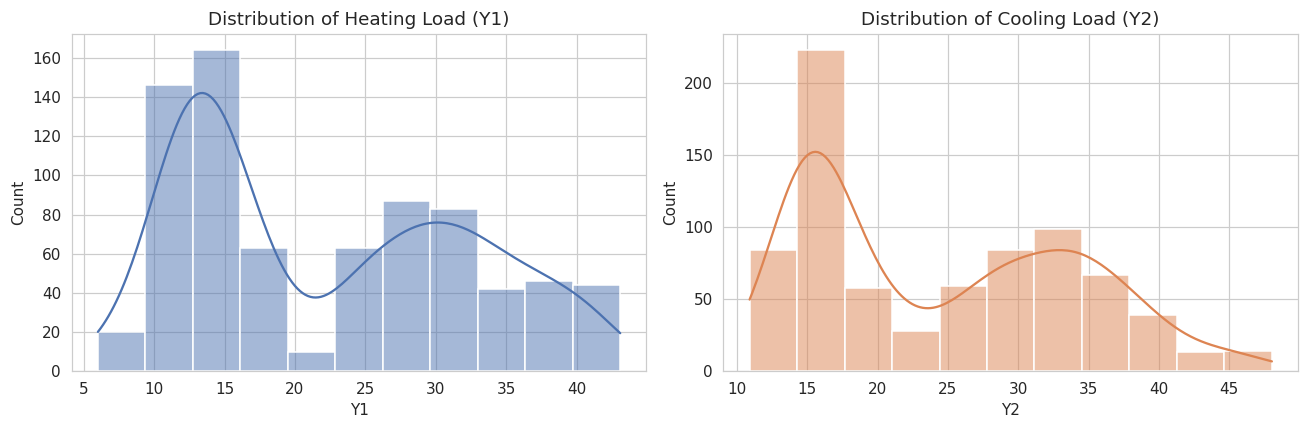

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["Y1"], kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribution of Heating Load (Y1)")
sns.histplot(df["Y2"], kde=True, ax=axes[1], color="#DD8452")
axes[1].set_title("Distribution of Cooling Load (Y2)")
plt.tight_layout()
plt.savefig("figures_target_distribution.png", bbox_inches="tight")
plt.show()

### 6b. Correlation Analysis

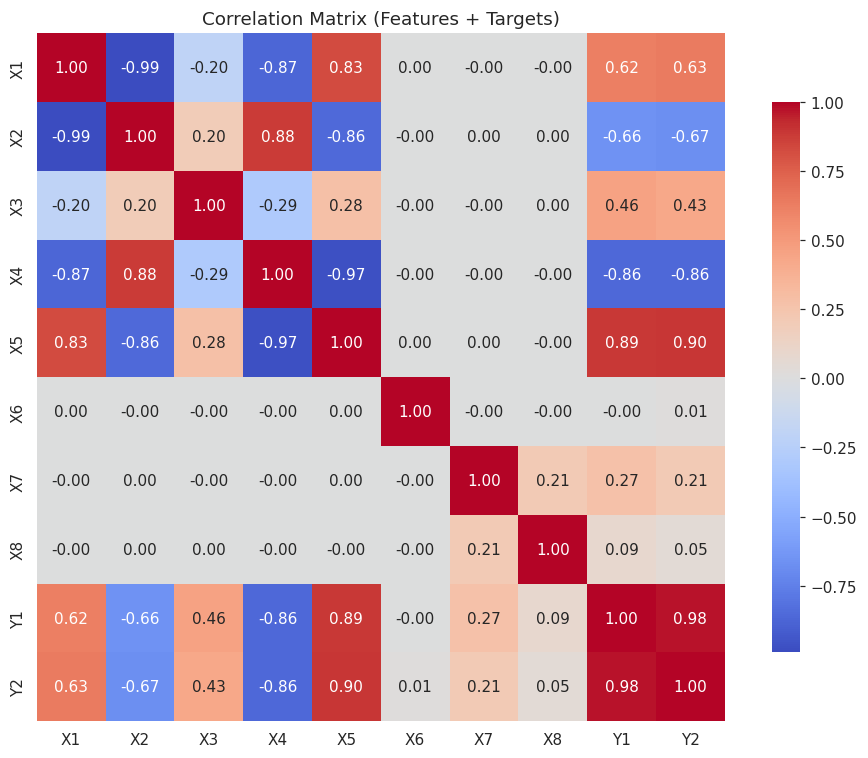

In [ ]:
plt.figure(figsize=(9, 7))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix (Features + Targets)")
plt.tight_layout()
plt.savefig("figures_correlation_matrix.png", bbox_inches="tight")
plt.show()

In [ ]:
print("Correlation of each feature with Y1 (Heating Load):")
print(corr["Y1"].drop(["Y1", "Y2"]).sort_values(ascending=False))
print("\nCorrelation of each feature with Y2 (Cooling Load):")
print(corr["Y2"].drop(["Y1", "Y2"]).sort_values(ascending=False))

Correlation of each feature with Y1 (Heating Load):
X5    0.889430
X1    0.622272
X3    0.455671
X7    0.269842
X8    0.087368
X6   -0.002587
X2   -0.658120
X4   -0.861828
Name: Y1, dtype: float64

Correlation of each feature with Y2 (Cooling Load):
X5    0.895785
X1    0.634339
X3    0.427117
X7    0.207505
X8    0.050525
X6    0.014290
X2   -0.672999
X4   -0.862547
Name: Y2, dtype: float64


### 6c. Feature Importance (Preliminary, via Random Forest)

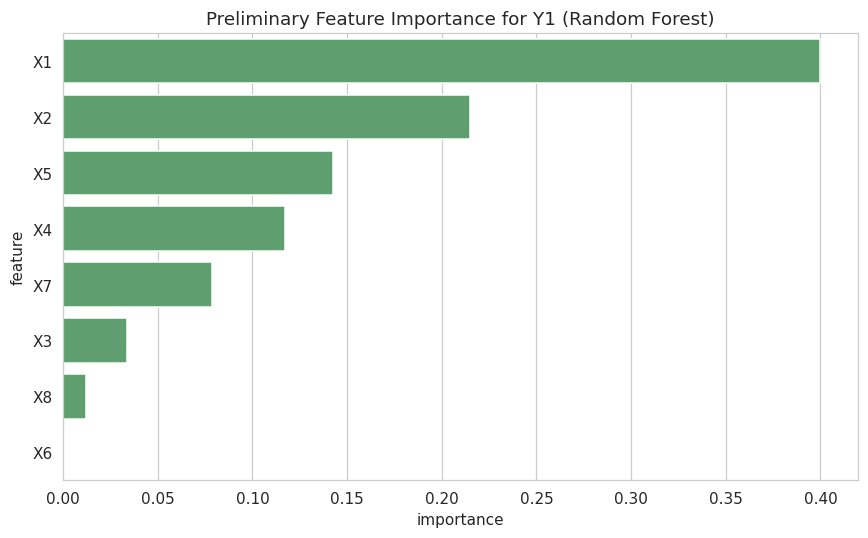

,feature,importance
0,X1,0.399876
1,X2,0.214841
4,X5,0.142455
3,X4,0.117322
6,X7,0.078462
2,X3,0.033930
7,X8,0.012353
5,X6,0.000761


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_importance_probe = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE)
rf_importance_probe.fit(X_train, y_train["Y1"])

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_importance_probe.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x="importance", y="feature", color="#55A868")
plt.title("Preliminary Feature Importance for Y1 (Random Forest)")
plt.tight_layout()
plt.savefig("figures_feature_importance_preliminary.png", bbox_inches="tight")
plt.show()

importance_df

## Step 7: Multi-Output Model Training

Five models are trained for the **multi-output regression task** (predicting `Y1` and `Y2` simultaneously):
1. Linear Regression
2. Random Forest
3. XGBoost
4. LightGBM
5. CatBoost

Tree-based models are trained on **unscaled** features (their natural input); Linear Regression uses **scaled** features.

### 7a. Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

print("Linear Regression trained.")

Linear Regression trained.


### 7b. Random Forest

In [ ]:
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=RANDOM_STATE
)

rf.fit(X_train, y_train)

print("Random Forest trained.")

Random Forest trained.


### 7c. XGBoost

In [ ]:
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor

xgb = MultiOutputRegressor(
    XGBRegressor(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        random_state=RANDOM_STATE
    )
)

xgb.fit(X_train, y_train)

print("XGBoost trained.")

XGBoost trained.


### 7d. LightGBM

In [ ]:
from lightgbm import LGBMRegressor

lgbm = MultiOutputRegressor(
    LGBMRegressor(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        random_state=RANDOM_STATE,
        verbose=-1
    )
)

lgbm.fit(X_train, y_train)

print("LightGBM trained.")

LightGBM trained.


### 7e. CatBoost

In [ ]:
from catboost import CatBoostRegressor

cat = MultiOutputRegressor(
    CatBoostRegressor(
        iterations=500,
        random_state=RANDOM_STATE,
        verbose=0
    )
)

cat.fit(X_train, y_train)

print("CatBoost trained.")

CatBoost trained.


## Step 8: Model Evaluation

Metrics computed per target (`Y1`, `Y2`) and as an overall average: **MAE**, **RMSE**, **R²**.

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

models = {
    "Linear Regression": (lr, X_test_scaled),
    "Random Forest": (rf, X_test),
    "XGBoost": (xgb, X_test),
    "LightGBM": (lgbm, X_test),
    "CatBoost": (cat, X_test),
}

results = []

for name, (model, X_eval) in models.items():
    pred = model.predict(X_eval)
    pred = np.array(pred)

    for i, target in enumerate(target_names):
        mae = mean_absolute_error(y_test[target], pred[:, i])
        rmse = np.sqrt(mean_squared_error(y_test[target], pred[:, i]))
        r2 = r2_score(y_test[target], pred[:, i])
        results.append({
            "Model": name,
            "Target": target,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        })

    # Overall (averaged across both targets)
    mae_overall = mean_absolute_error(y_test, pred)
    rmse_overall = np.sqrt(mean_squared_error(y_test, pred))
    r2_overall = r2_score(y_test, pred)
    results.append({
        "Model": name,
        "Target": "Overall",
        "MAE": mae_overall,
        "RMSE": rmse_overall,
        "R2": r2_overall
    })

results_df = pd.DataFrame(results)
results_df

,Model,Target,MAE,RMSE,R2
0,Linear Regression,Y1,2.182073,3.025427,0.912185
1,Linear Regression,Y2,2.195295,3.145382,0.893226
2,Linear Regression,Overall,2.188684,3.085987,0.902705
3,Random Forest,Y1,0.345226,0.493851,0.997660
4,Random Forest,Y2,1.163199,1.901992,0.960957
5,Random Forest,Overall,0.754212,1.389507,0.979309
6,XGBoost,Y1,0.261083,0.394132,0.998510
7,XGBoost,Y2,0.508377,0.829912,0.992567
8,XGBoost,Overall,0.384730,0.649651,0.995538
9,LightGBM,Y1,0.311154,0.418042,0.998323


In [ ]:
# Clean comparison table: Overall performance only
overall_comparison = results_df[results_df["Target"] == "Overall"].drop(columns="Target").reset_index(drop=True)
overall_comparison = overall_comparison.sort_values("R2", ascending=False).reset_index(drop=True)
overall_comparison

,Model,MAE,RMSE,R2
0,CatBoost,0.345645,0.536032,0.996967
1,XGBoost,0.384730,0.649651,0.995538
2,LightGBM,0.512983,0.814257,0.992949
3,Random Forest,0.754212,1.389507,0.979309
4,Linear Regression,2.188684,3.085987,0.902705


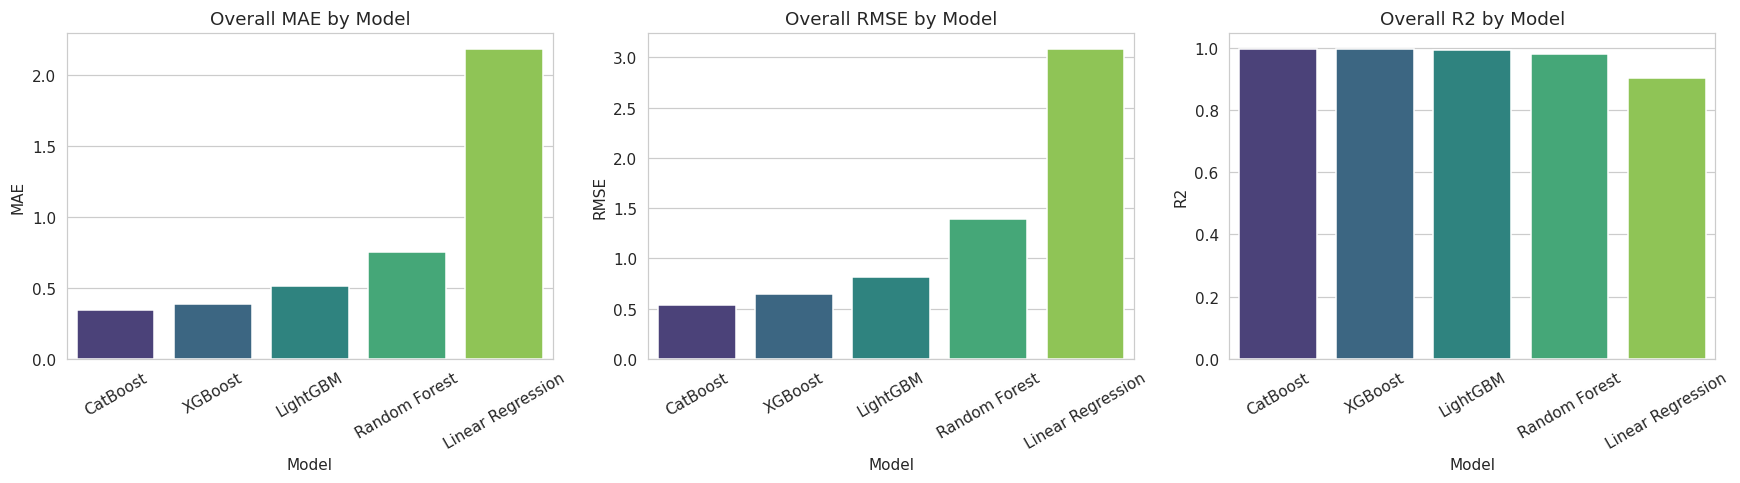

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
metrics = ["MAE", "RMSE", "R2"]
colors = sns.color_palette("viridis", len(overall_comparison))

for ax, metric in zip(axes, metrics):
    sns.barplot(data=overall_comparison, x="Model", y=metric, ax=ax, palette=colors)
    ax.set_title(f"Overall {metric} by Model")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("figures_model_comparison.png", bbox_inches="tight")
plt.show()

## Step 9: Best Model Selection

The best model is selected based on the highest **overall R²** (you may substitute lowest RMSE if preferred for your paper's framing).

In [ ]:
best_model_name = overall_comparison.iloc[0]["Model"]
print(f"Best performing model (by overall R2): {best_model_name}")

best_model_map = {
    "Linear Regression": lr,
    "Random Forest": rf,
    "XGBoost": xgb,
    "LightGBM": lgbm,
    "CatBoost": cat,
}

best_model = best_model_map[best_model_name]
best_model_X_train = X_train_scaled if best_model_name == "Linear Regression" else X_train
best_model_X_test = X_test_scaled if best_model_name == "Linear Regression" else X_test

print(f"Best model object: {best_model}")

Best performing model (by overall R2): CatBoost
Best model object: MultiOutputRegressor(estimator=CatBoostRegressor(iterations=500, loss_function='RMSE', random_state=42, verbose=0))


## Step 10: SHAP Explainability — Global Explanation

> **Note:** `shap.TreeExplainer` requires a tree-based model. If `best_model_name` is "Linear Regression", switch to `shap.LinearExplainer` (handled automatically below). For CatBoost/XGBoost/LightGBM/RandomForest with `MultiOutputRegressor`, the explainer is built per-target estimator: `best_model.estimators_[0]` → Y1, `best_model.estimators_[1]` → Y2. Random Forest (not wrapped in `MultiOutputRegressor`) natively supports multi-output, so it is handled separately.

In [ ]:
import shap

def get_estimator(model, model_name, target_index):
    """Return the underlying single-output estimator for a given target index."""
    if model_name == "Random Forest":
        # RandomForestRegressor handles multi-output natively (no MultiOutputRegressor wrapper)
        return model
    elif model_name == "Linear Regression":
        return model
    else:
        return model.estimators_[target_index]

# --- Heating Load (Y1) ---
estimator_y1 = get_estimator(best_model, best_model_name, 0)

if best_model_name == "Linear Regression":
    explainer_y1 = shap.LinearExplainer(estimator_y1, best_model_X_train)
    shap_values_y1 = explainer_y1.shap_values(best_model_X_test)
    if isinstance(shap_values_y1, list):
        shap_values_y1 = shap_values_y1[0]
    elif shap_values_y1.ndim == 3:
        shap_values_y1 = shap_values_y1[:, :, 0]
elif best_model_name == "Random Forest":
    explainer_y1 = shap.TreeExplainer(estimator_y1)
    shap_values_full = explainer_y1.shap_values(best_model_X_test)
    # shap_values_full is a list [Y1_values, Y2_values] for multi-output RF
    shap_values_y1 = shap_values_full[0] if isinstance(shap_values_full, list) else shap_values_full[..., 0]
else:
    explainer_y1 = shap.TreeExplainer(estimator_y1)
    shap_values_y1 = explainer_y1.shap_values(best_model_X_test)

print("SHAP values computed for Y1 (Heating Load). Shape:", np.array(shap_values_y1).shape)

SHAP values computed for Y1 (Heating Load). Shape: (154, 8)


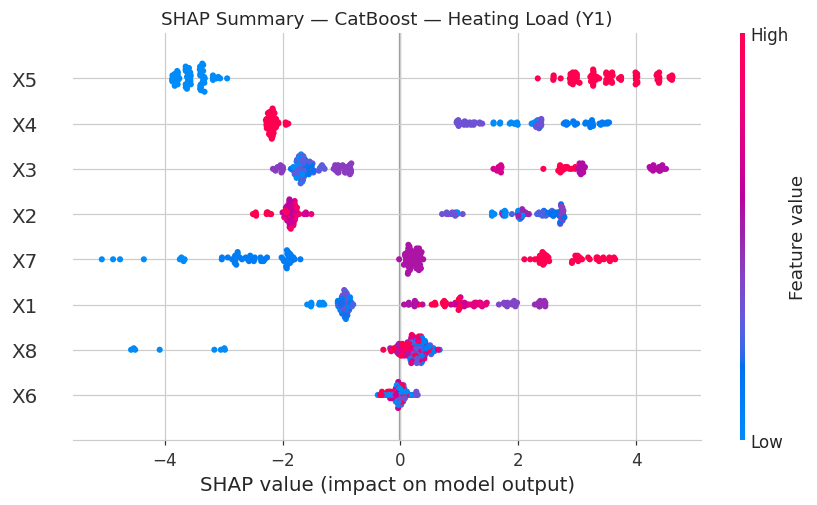

In [ ]:
shap.summary_plot(shap_values_y1, best_model_X_test, show=False)
plt.title(f"SHAP Summary — {best_model_name} — Heating Load (Y1)")
plt.tight_layout()
plt.savefig("figures_shap_summary_Y1.png", bbox_inches="tight")
plt.show()

**Cooling Load (Y2):**

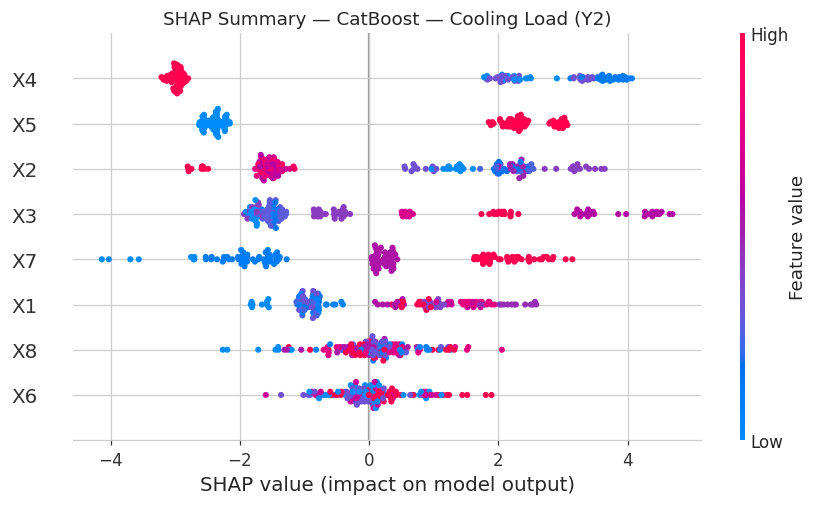

In [ ]:
estimator_y2 = get_estimator(best_model, best_model_name, 1)

if best_model_name == "Linear Regression":
    explainer_y2 = shap.LinearExplainer(estimator_y2, best_model_X_train)
    shap_values_y2 = explainer_y2.shap_values(best_model_X_test)
    if isinstance(shap_values_y2, list):
        shap_values_y2 = shap_values_y2[1] if len(shap_values_y2) > 1 else shap_values_y2[0]
    elif shap_values_y2.ndim == 3:
        shap_values_y2 = shap_values_y2[:, :, 1]
elif best_model_name == "Random Forest":
    explainer_y2 = shap.TreeExplainer(estimator_y2)
    shap_values_full2 = explainer_y2.shap_values(best_model_X_test)
    shap_values_y2 = shap_values_full2[1] if isinstance(shap_values_full2, list) else shap_values_full2[..., 1]
else:
    explainer_y2 = shap.TreeExplainer(estimator_y2)
    shap_values_y2 = explainer_y2.shap_values(best_model_X_test)

shap.summary_plot(shap_values_y2, best_model_X_test, show=False)
plt.title(f"SHAP Summary — {best_model_name} — Cooling Load (Y2)")
plt.tight_layout()
plt.savefig("figures_shap_summary_Y2.png", bbox_inches="tight")
plt.show()

## Step 11: SHAP Explainability — Local Explanation

Explains a single prediction (the first test instance) for Y1.

In [ ]:
shap.initjs()

sample_idx = 0

if best_model_name == "Linear Regression":
    expected_value_y1 = explainer_y1.expected_value
    if isinstance(expected_value_y1, (list, np.ndarray)):
        expected_value_y1 = expected_value_y1[0]
else:
    expected_value_y1 = explainer_y1.expected_value
    if isinstance(expected_value_y1, (list, np.ndarray)):
        expected_value_y1 = expected_value_y1[0]

force_plot = shap.force_plot(
    expected_value_y1,
    shap_values_y1[sample_idx],
    best_model_X_test.iloc[sample_idx]
)
force_plot

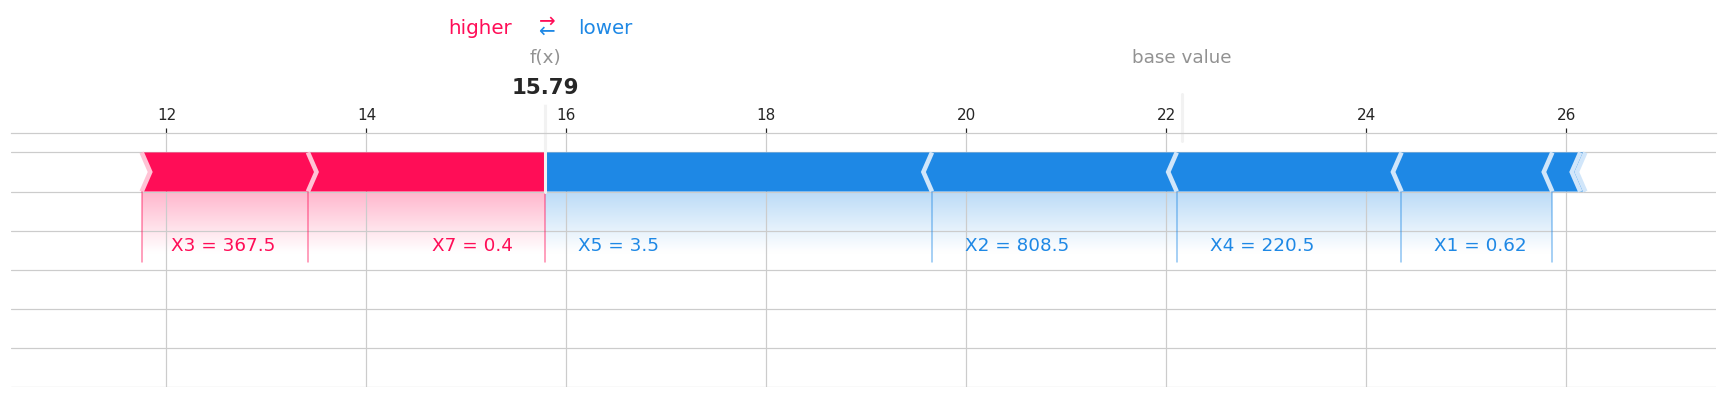

In [ ]:
# Static (matplotlib) version -- renders reliably when exporting the notebook to PDF/HTML
shap.force_plot(
    expected_value_y1,
    shap_values_y1[sample_idx],
    best_model_X_test.iloc[sample_idx],
    matplotlib=True,
    show=False
)
plt.savefig("figures_shap_local_force_Y1.png", bbox_inches="tight", dpi=150)
plt.show()

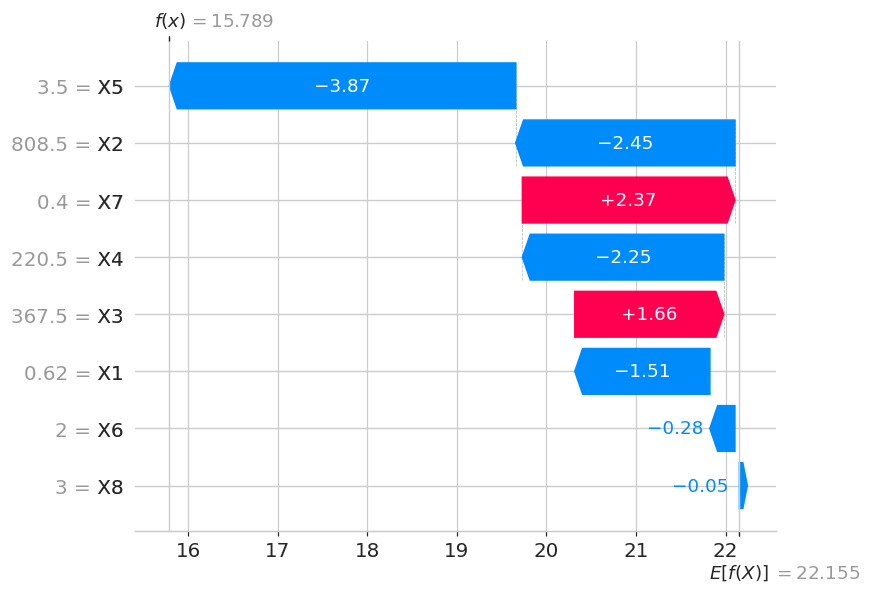

In [ ]:
# Waterfall plot -- alternative, often clearer local explanation
shap_exp = shap.Explanation(
    values=shap_values_y1[sample_idx],
    base_values=expected_value_y1,
    data=best_model_X_test.iloc[sample_idx].values,
    feature_names=feature_names
)
shap.plots.waterfall(shap_exp, show=False)
plt.tight_layout()
plt.savefig("figures_shap_waterfall_Y1.png", bbox_inches="tight")
plt.show()

## Step 12: Counterfactual Generation — Method 1: DiCE

DiCE requires a **classification-style or regression-style sklearn-compatible model**. We use the single-output estimator for `Y1` (Heating Load) from the best model.

> DiCE's sklearn backend works directly with regressors that expose `.predict()`. We use the unscaled feature space (`X` / `df`) for interpretability of counterfactuals (so design recommendations are in original units).

In [ ]:
import dice_ml

# Build a combined dataframe with features + the Y1 target for DiCE's data interface
dice_df = pd.concat([X, Y["Y1"]], axis=1)

data_dice = dice_ml.Data(
    dataframe=dice_df,
    continuous_features=['X1', 'X2', 'X3', 'X4', 'X5', 'X7'],
    outcome_name='Y1'
)

# Use the Y1 estimator from the best model, trained on UNSCALED features for direct interpretability.
# If the best model is Linear Regression, retrain a quick unscaled-feature version for DiCE compatibility.
if best_model_name == "Linear Regression":
    dice_estimator = LinearRegression().fit(X_train, y_train["Y1"])
elif best_model_name == "Random Forest":
    dice_estimator = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE).fit(X_train, y_train["Y1"])
else:
    dice_estimator = estimator_y1  # already fit on unscaled X_train for Y1

model_dice = dice_ml.Model(
    model=dice_estimator,
    backend="sklearn",
    model_type="regressor"
)

print("DiCE data and model interface ready.")

DiCE data and model interface ready.


In [ ]:
exp_dice = dice_ml.Dice(data_dice, model_dice, method="random")

query_instance = X_test.iloc[0:1]
print("Query instance (original):")
print(query_instance)
print("\nActual Y1 (Heating Load):", y_test["Y1"].iloc[0])
print("Model prediction:", dice_estimator.predict(query_instance)[0])

Query instance (original):
       X1     X2     X3     X4   X5  X6   X7  X8
668  0.62  808.5  367.5  220.5  3.5   2  0.4   3

Actual Y1 (Heating Load): 16.47
Model prediction: 15.788874666803931


In [ ]:
cf = exp_dice.generate_counterfactuals(
    query_instances=query_instance,
    total_CFs=5,
    desired_range=[10, 20]
)

cf.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:00<00:00,  8.36it/s]

Query instance (original outcome : 16.0)


,X1,X2,X3,X4,X5,X6,X7,X8,Y1
0,0.62,808.5,367.5,220.5,3.5,2,0.4,3,16.0



Diverse Counterfactual set (new outcome: [10, 20])


,X1,X2,X3,X4,X5,X6,X7,X8,Y1
0,-,-,396.5,-,-,-,-,-,15.787982940673828
1,-,-,277.8,-,-,3.0,-,-,15.108968734741211
2,-,742.7,-,-,-,-,-,-,16.659963607788086
3,-,-,-,204.9,-,-,-,-,15.788874626159668
4,0.83,-,-,196.1,-,-,-,-,19.543777465820312


## Step 13: Add Feasibility Constraints

Real buildings cannot have arbitrary geometry. Constraints are added so counterfactuals only suggest **physically realistic** design changes.

In [ ]:
permitted_range = {
    "X1": [0.62, 0.98],   # Relative Compactness -- realistic architectural range
    "X7": [0.0, 0.4],     # Glazing Area -- realistic range
}

cf_constrained = exp_dice.generate_counterfactuals(
    query_instances=query_instance,
    total_CFs=5,
    desired_range=[10, 20],
    permitted_range=permitted_range
)

cf_constrained.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:00<00:00,  8.05it/s]

Query instance (original outcome : 16.0)


,X1,X2,X3,X4,X5,X6,X7,X8,Y1
0,0.62,808.5,367.5,220.5,3.5,2,0.4,3,16.0



Diverse Counterfactual set (new outcome: [10, 20])


,X1,X2,X3,X4,X5,X6,X7,X8,Y1
0,-,-,305.0,169.7,-,-,-,-,18.533966064453125
1,-,-,-,-,5.1,-,-,4.0,16.366579055786133
2,-,-,396.1,-,4.5,-,-,-,15.787982940673828
3,0.9,-,-,-,4.4,-,-,-,19.752180099487305
4,-,-,314.9,-,-,-,0.27,-,13.440103530883789


## Step 14: Counterfactual Generation — Method 2: Genetic Algorithm (DEAP / NSGA-II)

This is the **novelty component**: an independent counterfactual search using a multi-objective genetic algorithm (NSGA-II), optimizing simultaneously for:
1. **Proximity** — minimize distance to the original instance
2. **Validity** — hit the desired target range
3. **Sparsity** — minimize number of changed features

In [ ]:
from deap import base, creator, tools, algorithms
import random

# Feature bounds taken from the observed training data range (keeps search realistic)
feature_bounds = {col: (X_train[col].min(), X_train[col].max()) for col in feature_names}
print("Feature bounds used by the genetic algorithm:")
for k, v in feature_bounds.items():
    print(f"  {k}: {v}")

Feature bounds used by the genetic algorithm:
  X1: (0.62, 0.98)
  X2: (514.5, 808.5)
  X3: (245.0, 416.5)
  X4: (110.25, 220.5)
  X5: (3.5, 7.0)
  X6: (2, 5)
  X7: (0.0, 0.4)
  X8: (0, 5)


In [ ]:
# Genetic algorithm setup
if "FitnessMin" in creator.__dict__:
    del creator.FitnessMin
if "Individual" in creator.__dict__:
    del creator.Individual

creator.create("FitnessMin", base.Fitness, weights=(-1.0, -1.0, -1.0))  # minimize all 3 objectives
creator.create("Individual", list, fitness=creator.FitnessMin)

toolbox = base.Toolbox()

original_instance = query_instance.iloc[0].values
desired_min, desired_max = 10, 20

def init_individual():
    return creator.Individual([
        random.uniform(feature_bounds[f][0], feature_bounds[f][1]) for f in feature_names
    ])

def predict_y1(individual):
    arr = np.array(individual).reshape(1, -1)
    df_ind = pd.DataFrame(arr, columns=feature_names)
    return dice_estimator.predict(df_ind)[0]

def evaluate(individual):
    pred = predict_y1(individual)

    # Validity: distance outside the desired range (0 if inside the range)
    if desired_min <= pred <= desired_max:
        validity_penalty = 0.0
    else:
        validity_penalty = min(abs(pred - desired_min), abs(pred - desired_max))

    # Proximity: normalized Euclidean distance to original instance
    diffs = [(individual[i] - original_instance[i]) / (feature_bounds[feature_names[i]][1] - feature_bounds[feature_names[i]][0] + 1e-9)
              for i in range(len(feature_names))]
    proximity = float(np.sqrt(np.sum(np.square(diffs))))

    # Sparsity: number of meaningfully changed features
    sparsity = sum(1 for i in range(len(feature_names)) if abs(diffs[i]) > 0.05)

    return validity_penalty, proximity, sparsity

toolbox.register("individual", init_individual)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("evaluate", evaluate)
toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=0.1, indpb=0.3)
toolbox.register("select", tools.selNSGA2)

print("NSGA-II toolbox configured.")

NSGA-II toolbox configured.


In [ ]:
random.seed(RANDOM_STATE)

POP_SIZE = 100
N_GEN = 40

population = toolbox.population(n=POP_SIZE)

algo_result = algorithms.eaMuPlusLambda(
    population,
    toolbox,
    mu=POP_SIZE,
    lambda_=POP_SIZE,
    cxpb=0.5,
    mutpb=0.3,
    ngen=N_GEN,
    verbose=False
)

final_population = algo_result[0]
print(f"NSGA-II evolution complete: {N_GEN} generations, population size {POP_SIZE}.")

NSGA-II evolution complete: 40 generations, population size 100.


In [ ]:
# Extract the Pareto-optimal front and pick top candidates that satisfy validity
pareto_front = tools.sortNondominated(final_population, len(final_population), first_front_only=True)[0]

nsga_candidates = []
for ind in pareto_front:
    pred = predict_y1(ind)
    validity_penalty, proximity, sparsity = evaluate(ind)
    nsga_candidates.append({
        **{feature_names[i]: ind[i] for i in range(len(feature_names))},
        "Predicted_Y1": pred,
        "Validity_Penalty": validity_penalty,
        "Proximity": proximity,
        "Sparsity": sparsity
    })

nsga_df = pd.DataFrame(nsga_candidates).sort_values(["Validity_Penalty", "Proximity"]).reset_index(drop=True)
nsga_top5 = nsga_df.head(5)
nsga_top5

,X1,X2,X3,X4,X5,X6,X7,X8,Predicted_Y1,Validity_Penalty,Proximity,Sparsity
0,0.620157,808.687166,367.366731,220.297717,3.48745,1.998749,0.398597,3.009271,15.788875,0.0,0.005774,0


## Step 15: Counterfactual Evaluation Metrics & Method Comparison

Metrics:
- **Validity** — fraction of generated counterfactuals whose prediction falls in the desired range
- **Sparsity** — average number of changed features (lower = more interpretable/actionable)
- **Proximity** — average normalized Euclidean distance to the original instance (lower = more realistic)
- **Diversity** — average pairwise distance among generated counterfactuals (higher = more varied design options)

In [ ]:
def compute_metrics(cf_array, original, feature_bounds, desired_min, desired_max, predict_fn):
    """
    cf_array: list/array of counterfactual feature vectors (each shape = n_features)
    original: original instance feature vector
    predict_fn: function(vector) -> predicted Y1
    """
    n = len(cf_array)
    if n == 0:
        return {"Validity": np.nan, "Sparsity": np.nan, "Proximity": np.nan, "Diversity": np.nan}

    ranges = np.array([feature_bounds[f][1] - feature_bounds[f][0] + 1e-9 for f in feature_names])

    valid_count = 0
    sparsities = []
    proximities = []

    for cf_vec in cf_array:
        pred = predict_fn(cf_vec)
        if desired_min <= pred <= desired_max:
            valid_count += 1

        diffs = (np.array(cf_vec) - np.array(original)) / ranges
        sparsities.append(np.sum(np.abs(diffs) > 0.05))
        proximities.append(np.sqrt(np.sum(np.square(diffs))))

    # Diversity: mean pairwise distance
    pairwise_dists = []
    for i in range(n):
        for j in range(i + 1, n):
            d = np.sqrt(np.sum(np.square((np.array(cf_array[i]) - np.array(cf_array[j])) / ranges)))
            pairwise_dists.append(d)
    diversity = np.mean(pairwise_dists) if pairwise_dists else 0.0

    return {
        "Validity": valid_count / n,
        "Sparsity": np.mean(sparsities),
        "Proximity": np.mean(proximities),
        "Diversity": diversity
    }


# --- DiCE counterfactuals (constrained version) ---
dice_cf_df = cf_constrained.cf_examples_list[0].final_cfs_df
dice_cf_vectors = dice_cf_df[feature_names].values.tolist()

dice_metrics = compute_metrics(
    dice_cf_vectors, original_instance, feature_bounds,
    desired_min, desired_max, predict_y1
)

# --- NSGA-II counterfactuals ---
nsga_cf_vectors = nsga_top5[feature_names].values.tolist()

nsga_metrics = compute_metrics(
    nsga_cf_vectors, original_instance, feature_bounds,
    desired_min, desired_max, predict_y1
)

comparison_table = pd.DataFrame({
    "DiCE": dice_metrics,
    "NSGA-II": nsga_metrics
}).T

comparison_table

,Validity,Sparsity,Proximity,Diversity
DiCE,1.0,2.0,0.536665,0.728441
NSGA-II,1.0,0.0,0.005774,0.000000


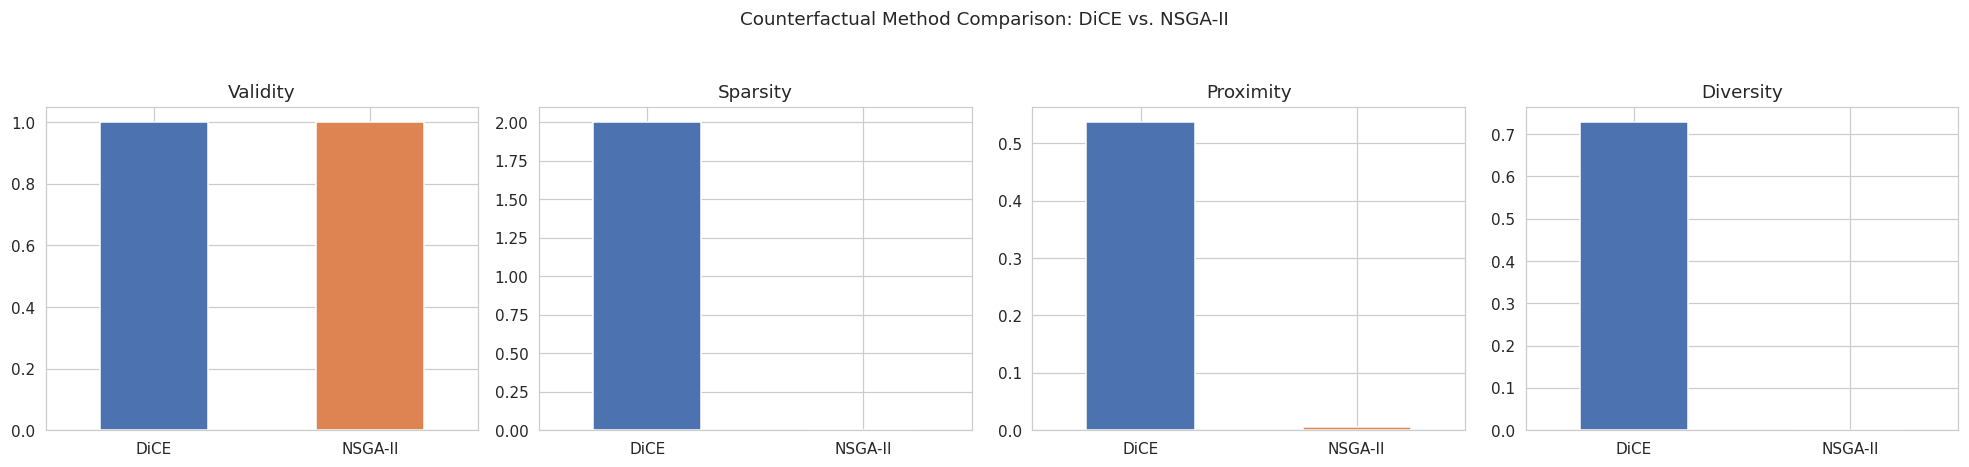

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
metric_cols = ["Validity", "Sparsity", "Proximity", "Diversity"]

for ax, m in zip(axes, metric_cols):
    comparison_table[m].plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
    ax.set_title(m)
    ax.set_xticklabels(comparison_table.index, rotation=0)

plt.suptitle("Counterfactual Method Comparison: DiCE vs. NSGA-II", y=1.05)
plt.tight_layout()
plt.savefig("figures_cf_method_comparison.png", bbox_inches="tight")
plt.show()

## Step 16: Design Recommendations

Translate the top counterfactual(s) into actionable building-design language for the paper's discussion section.

In [ ]:
def summarize_recommendation(cf_vector, original, feature_names, threshold=0.05, feature_bounds=feature_bounds):
    changes = []
    for i, f in enumerate(feature_names):
        rng = feature_bounds[f][1] - feature_bounds[f][0] + 1e-9
        delta_norm = (cf_vector[i] - original[i]) / rng
        if abs(delta_norm) > threshold:
            direction = "increase" if cf_vector[i] > original[i] else "decrease"
            changes.append(f"{direction} {f} from {original[i]:.3f} to {cf_vector[i]:.3f}")
    return changes


print("=== Recommendation derived from best DiCE counterfactual ===")
best_dice_cf = dice_cf_vectors[0]
for rec in summarize_recommendation(best_dice_cf, original_instance, feature_names):
    print(" -", rec)

print("\n=== Recommendation derived from best NSGA-II counterfactual ===")
best_nsga_cf = nsga_cf_vectors[0]
for rec in summarize_recommendation(best_nsga_cf, original_instance, feature_names):
    print(" -", rec)

=== Recommendation derived from best DiCE counterfactual ===
 - decrease X3 from 367.500 to 305.000
 - decrease X4 from 220.500 to 169.700

=== Recommendation derived from best NSGA-II counterfactual ===


## Summary

| Stage | Output |
|---|---|
| Best predictive model | Selected automatically in Step 9 by overall R² |
| Explainability | SHAP global (summary plots) + local (force/waterfall plots) for Y1 and Y2 |
| Counterfactuals | DiCE (gradient-free/random search) and NSGA-II (multi-objective genetic algorithm) |
| Novel contribution | Head-to-head comparison of DiCE vs. NSGA-II on Validity, Sparsity, Proximity, Diversity |
| Final deliverable | Actionable, feasibility-constrained design recommendations for reducing heating load |

All figures are saved to the working directory (`figures_*.png`) for direct inclusion in the paper.